# Benchmark - [Alibaba's Qwen 3.6 35B](https://huggingface.co/unsloth/Qwen3.6-35B-A3B-GGUF)

**Evaluation:** Tasks 01-07

**Hardware:** NVIDIA GeForce RTX 4070 SUPER

In [14]:
import textwrap

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

from benchmark_lib import (
  DATA_DIR,
  RUNS_PER_BATCH,
  SERIES,
  add_token_counts,
  compare_skills,
  latest_batches,
  load_runs,
  metric_table,
  plot_benchmark,
  plot_skill_summary,
  plot_timeouts,
  save_runs,
)

HARDWARE = "NVIDIA GeForce RTX 4070 SUPER"
MODEL_LABEL = "Qwen 3.6 35B"


In [3]:
MODEL_NAME = "qwen-3.6-35b"
benchmark_dir = DATA_DIR / "alibaba" / MODEL_NAME

if (not benchmark_dir.exists()):
  all_runs = load_runs(model="unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL", hardware=HARDWARE)
  all_runs = all_runs[all_runs['start_time'] > '2026-08-17']
  all_runs = all_runs[all_runs['interrupted'] == False]
  all_runs = (all_runs
    .sort_values('start_time', ascending=False)
    .groupby(['task', 'skills'], group_keys=False)
    .head(5))

  df = add_token_counts(latest_batches(all_runs))
  save_runs(df, benchmark_dir, redact=("openai",))
  display(all_runs)

Skipping /home/remotecroc/kse/term-3/courseproject/pyTCR_publication/test/01-data-loading/runs/20260803_210241 because /home/remotecroc/kse/term-3/courseproject/pyTCR_publication/test/01-data-loading/runs/20260803_210241/eval_result.json does not exist
Skipping /home/remotecroc/kse/term-3/courseproject/pyTCR_publication/test/07-epitope-databases/runs/20260815_002851_1 because /home/remotecroc/kse/term-3/courseproject/pyTCR_publication/test/07-epitope-databases/runs/20260815_002851_1/eval_result.json does not exist
Skipping /home/remotecroc/kse/term-3/courseproject/pyTCR_publication/test/07-epitope-databases/runs/20260815_012920_2 because /home/remotecroc/kse/term-3/courseproject/pyTCR_publication/test/07-epitope-databases/runs/20260815_012920_2/eval_result.json does not exist
Skipping /home/remotecroc/kse/term-3/courseproject/pyTCR_publication/test/07-epitope-databases/runs/20260815_101030_1 because /home/remotecroc/kse/term-3/courseproject/pyTCR_publication/test/07-epitope-databases/r

,task,run,start_time,skills,score,points,total,passed,structure_match,duration_seconds,timed_out,interrupted,model,harness,model_server,hardware,fields
255,07-epitope-databases,20260819_120235_n5,2026-08-19 12:02:46.217779,False,0.000000,0.000000,3,False,True,3600,True,False,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,{'top_antigen_species_normal': {'expected': 'S...
254,07-epitope-databases,20260819_111312_n4,2026-08-19 11:13:23.028151,False,0.000000,0.000000,3,False,False,2952,False,False,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,{'top_antigen_species_normal': {'expected': 'S...
253,07-epitope-databases,20260819_102931_n3,2026-08-19 10:29:43.396257,False,0.111111,0.333333,3,False,True,2608,False,False,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,{'top_antigen_species_normal': {'expected': 'S...
252,07-epitope-databases,20260819_092918_n2,2026-08-19 09:29:31.032890,False,0.000000,0.000000,3,False,True,3600,True,False,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,{'top_antigen_species_normal': {'expected': 'S...
251,07-epitope-databases,20260819_082906_n1,2026-08-19 08:29:18.378100,False,0.000000,0.000000,3,False,True,3600,True,False,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,{'top_antigen_species_normal': {'expected': 'S...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,01-data-loading,20260817_085548_s5,2026-08-17 08:55:49.737137,True,1.000000,5.000000,5,True,True,178,False,False,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085..."
29,01-data-loading,20260817_084943_s4,2026-08-17 08:49:44.398314,True,0.800000,4.000000,5,False,True,364,False,False,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 3353..."
28,01-data-loading,20260817_084400_s3,2026-08-17 08:44:01.768080,True,1.000000,5.000000,5,True,True,341,False,False,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085..."
27,01-data-loading,20260817_084124_s2,2026-08-17 08:41:25.364433,True,1.000000,5.000000,5,True,True,155,False,False,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085..."


In [4]:
benchmark = pd.read_csv(benchmark_dir / "benchmark.csv")
benchmark["start_time"] = pd.to_datetime(benchmark["start_time"])
benchmark.head()


,task,run,start_time,skills,score,points,total,passed,structure_match,duration_seconds,...,model,harness,model_server,hardware,fields,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,total_tokens
0,01-data-loading,20260817_085847_n1,2026-08-17 08:58:49.194810,False,1.0,5.0,5,True,True,209,...,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085...",14126,5580,200513,0,220219
1,01-data-loading,20260817_090218_n2,2026-08-17 09:02:20.048317,False,1.0,5.0,5,True,True,229,...,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085...",7868,6097,125985,0,139950
2,01-data-loading,20260817_090609_n3,2026-08-17 09:06:10.737089,False,1.0,5.0,5,True,True,465,...,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085...",82369,7405,726353,0,816127
3,01-data-loading,20260817_091356_n4,2026-08-17 09:13:57.415844,False,1.0,5.0,5,True,True,215,...,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085...",18505,5422,230634,0,254561
4,01-data-loading,20260817_091732_n5,2026-08-17 09:17:33.944983,False,1.0,5.0,5,True,True,220,...,unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL,pi,llama.cpp,NVIDIA GeForce RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085...",13658,6100,186499,0,206257


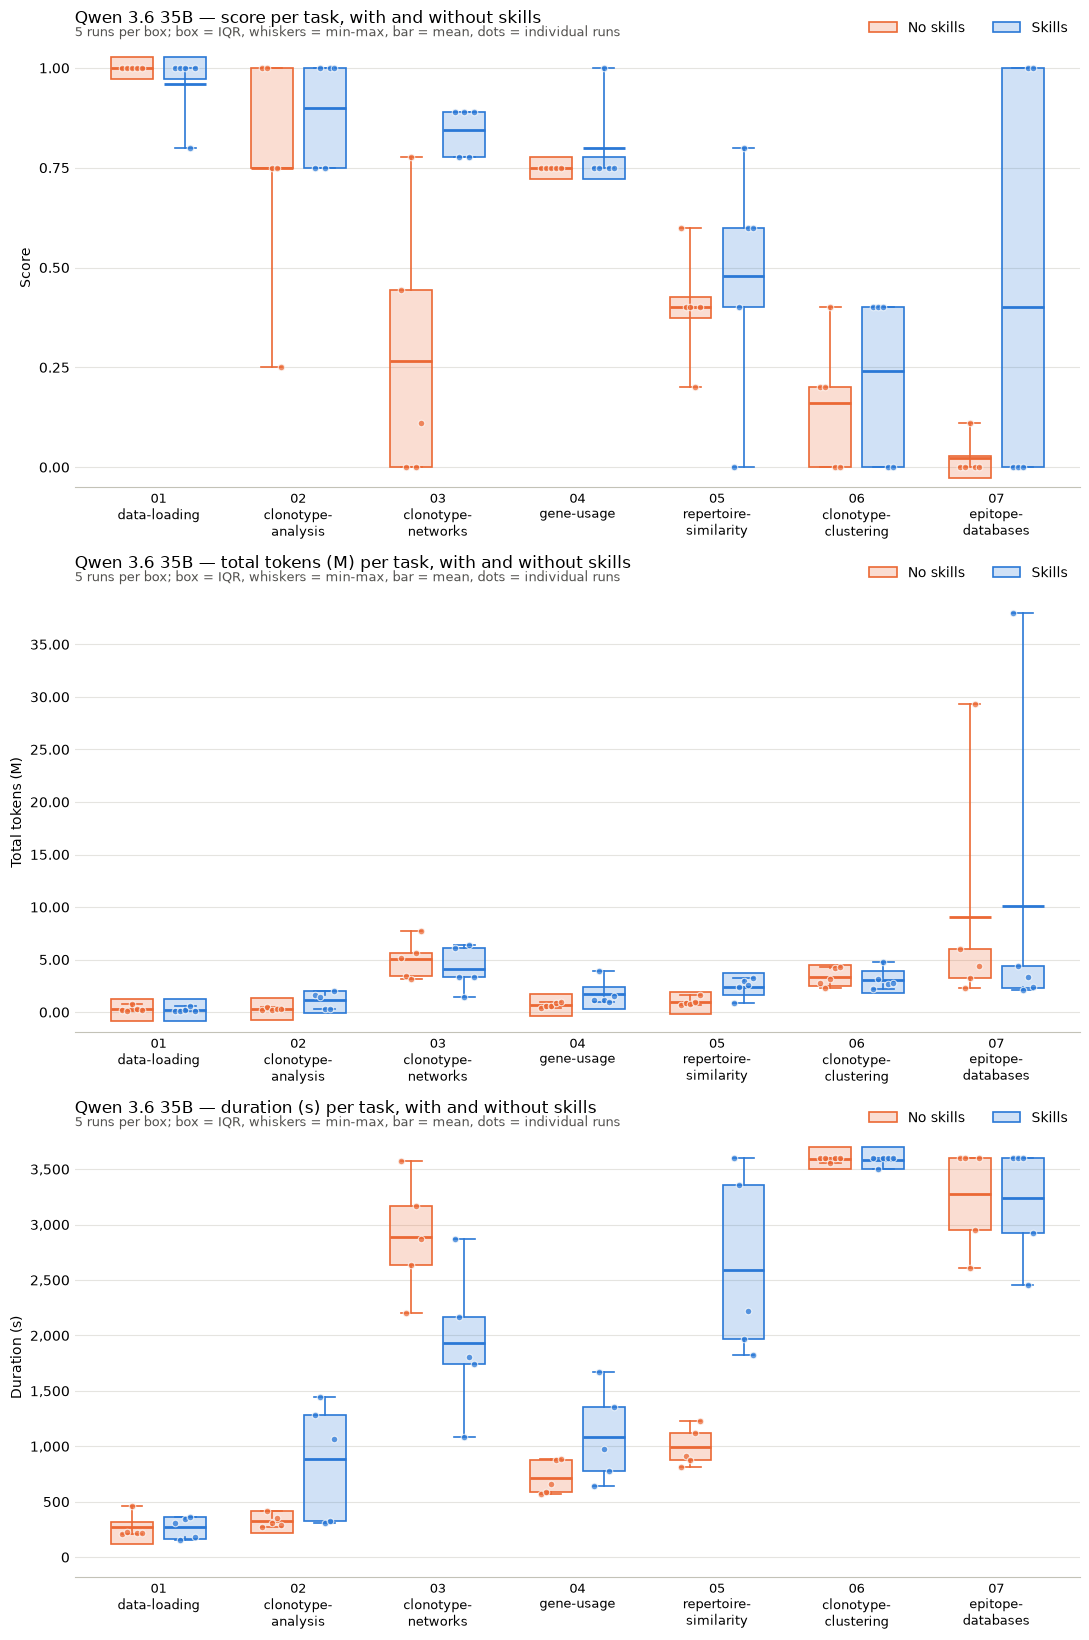

In [5]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(11, 5.5 * 3))
plot_benchmark(benchmark, column="score", model_label=MODEL_LABEL, ax=axs[0])
plot_benchmark(benchmark, column="total_tokens", model_label=MODEL_LABEL, ax=axs[1])
plot_benchmark(benchmark, column="duration_seconds", model_label=MODEL_LABEL, ax=axs[2])
fig.tight_layout()
plt.show()


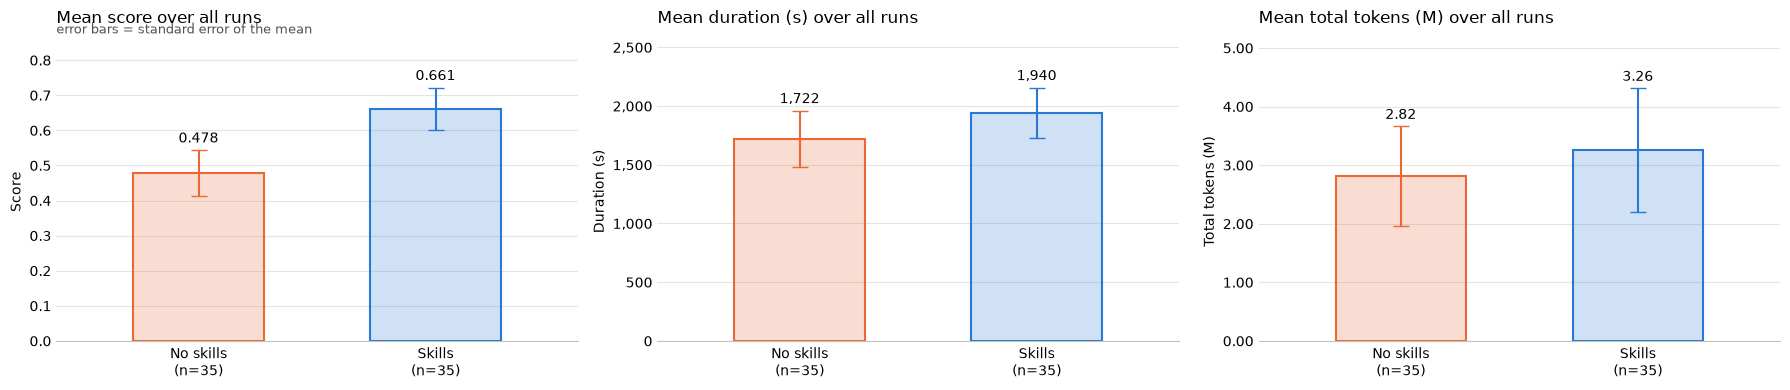

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(6 * 3, 4))
plot_skill_summary(benchmark, axs=axs)
fig.tight_layout()
plt.show()


In [7]:
significance = compare_skills(benchmark)


In [8]:
metric_table(significance, "score")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,0.478413,0.660635,0.182222,0.049040,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,1.000000,0.960000,-0.040000,0.423711,0.569826,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,0.750000,0.900000,0.150000,0.488422,0.569826,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,0.266667,0.844444,0.577778,0.018119,0.126832,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,0.750000,0.800000,0.050000,0.423711,0.569826,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,0.400000,0.480000,0.080000,0.444707,0.569826,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,0.160000,0.240000,0.080000,0.576150,0.576150,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,0.022222,0.400000,0.377778,0.438578,0.569826,False
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,0.478413,0.660635,0.182222,0.031250,NaN,False


In [9]:
metric_table(significance, "duration_seconds")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,1721.942857,1940.057143,218.114286,0.357640,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,267.600000,268.600000,1.000000,1.000000,1.000000,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,326.400000,885.600000,559.200000,0.095238,0.222222,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,2891.000000,1932.600000,-958.400000,0.031746,0.111111,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,715.200000,1082.800000,367.600000,0.150794,0.263889,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,990.600000,2594.000000,1603.400000,0.007937,0.055556,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,3590.800000,3580.000000,-10.800000,0.797170,1.000000,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,3272.000000,3236.800000,-35.200000,0.906329,1.000000,False
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,1721.942857,1940.057143,218.114286,0.687500,NaN,False


In [10]:
metric_table(significance, "total_tokens")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,2.818006e+06,3.260504e+06,442498.2,0.404296,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,3.274228e+05,2.456432e+05,-81779.6,0.309524,0.541667,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,3.019530e+05,1.128104e+06,826151.0,0.150794,0.351852,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,5.012359e+06,4.128466e+06,-883893.2,0.690476,0.690476,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,6.877126e+05,1.742075e+06,1054362.2,0.015873,0.111111,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,9.971186e+05,2.428525e+06,1431406.8,0.055556,0.194444,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,3.345397e+06,3.092536e+06,-252861.4,0.690476,0.690476,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,9.054080e+06,1.005818e+07,1004101.6,0.690476,0.690476,False
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,2.818006e+06,3.260504e+06,442498.2,0.296875,NaN,False


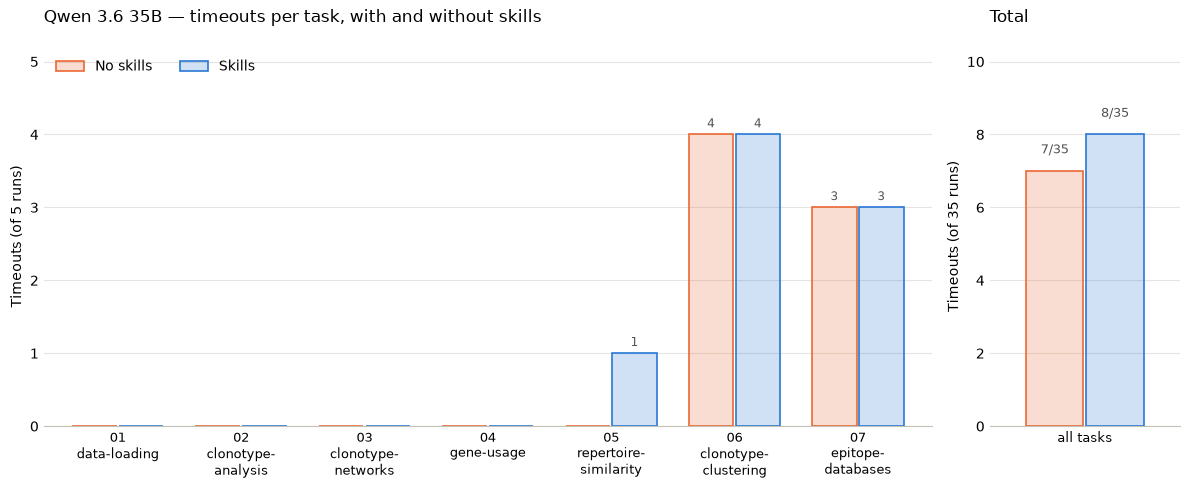

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
plot_timeouts(benchmark, model_label=MODEL_LABEL, axs=axs)
fig.tight_layout()
plt.show()